<div style="background:linear-gradient(135deg,#0a1230 0%,#141d44 55%,#1b1448 100%);border-radius:18px;padding:36px 32px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#00d4ff;font-weight:700;text-transform:uppercase">Part III · Visualizing Data &nbsp;|&nbsp; Chapter 16</div>
  <div style="font-size:40px;font-weight:900;line-height:1.1;margin:10px 0 6px">Multivariate &amp; Specialized Visuals <span style="color:#00d4ff">🐍 Notebook</span></div>
  <div style="font-size:16px;color:#b9c2e0;max-width:720px;line-height:1.6">Five demos for going past two dimensions: the correlation heatmap and scatterplot matrix that open every EDA, the Lorenz curve and its Gini number, honest faceting, and why a bubble must be sized by area.</div>
  <div style="margin-top:18px;font-size:13px;color:#8892b0">Author: <b style="color:#e8eaf6">John Fisher</b> &nbsp;·&nbsp; Statistics, Data Science and AI: A Visual Handbook &nbsp;·&nbsp; 2026</div>
</div>

### 🎯 What you'll build in this notebook

| # | Demo | Idea it builds |
|---|------|----------------|
| 1 | Correlation heatmap | every pairwise correlation, one diverging grid |
| 2 | Scatterplot matrix | all pairwise relationships and shapes at once |
| 3 | Lorenz curve & Gini | a curve and its inequality number |
| 4 | Small multiples | add a dimension honestly with shared axes |
| 5 | Bubble: area not radius | a third variable sized correctly |

---

## ⚙️ Setup, imports & the book's plotting style

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

rng = np.random.default_rng(16)

NAVY="#0a1230"; INK="#1a2138"; INK_SOFT="#4a5578"
CYAN="#0891b2"; PURPLE="#7c3aed"; AMBER="#d97706"; GREEN="#059669"; PINK="#db2777"; BLUE="#2563eb"; GRID="#e6e9f2"
plt.rcParams.update({
    "figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
    "axes.edgecolor":GRID,"axes.linewidth":1.2,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,
    "axes.spines.top":False,"axes.spines.right":False,"axes.titlesize":12.5,"axes.titleweight":"bold","axes.titlecolor":INK,
    "axes.labelcolor":INK_SOFT,"axes.labelsize":10.5,"xtick.color":INK_SOFT,"ytick.color":INK_SOFT,"legend.frameon":False,
})

iris = load_iris(as_frame=True)
df = iris.frame.rename(columns={c: c.replace(" (cm)","").replace(" ","_") for c in iris.frame.columns})
df["species"] = pd.Categorical.from_codes(iris.target, iris.target_names)
feat = ["sepal_length","sepal_width","petal_length","petal_width"]
print("iris loaded:", df.shape, "| features:", feat)

iris loaded: (150, 6) | features: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


<div style="background:#e0f7fb;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0891b2;letter-spacing:1px">DEMO 1 · CORRELATION HEATMAP</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🔥 Every pair of correlations at a glance</div>
<div style="color:#4a5578;margin-top:6px">The first cell of most multivariate analyses. Color each cell by the correlation of two variables on a DIVERGING scale centered at 0, because +1 and -1 mean opposite things. Annotate when the grid is small, and show only the lower triangle to drop the redundant mirror.</div>
</div>

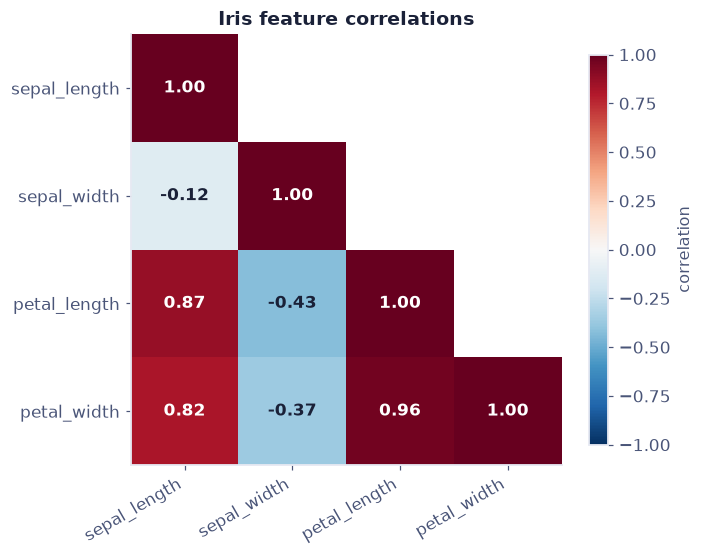

petal_length & petal_width are almost perfectly correlated (~0.96): redundant features.


In [2]:
corr = df[feat].corr().values
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)     # hide the redundant upper triangle
disp = np.where(mask, np.nan, corr)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(disp, cmap="RdBu_r", vmin=-1, vmax=1)    # diverging, centered at 0
ax.set_xticks(range(len(feat))); ax.set_xticklabels(feat, rotation=30, ha="right")
ax.set_yticks(range(len(feat))); ax.set_yticklabels(feat)
ax.grid(False)
for i in range(len(feat)):
    for j in range(len(feat)):
        if not mask[i, j]:
            ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
                    color="white" if abs(corr[i,j])>0.55 else INK, fontweight="bold")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("Iris feature correlations"); plt.tight_layout(); plt.show()
print("petal_length & petal_width are almost perfectly correlated (~0.96): redundant features.")

<div style="background:#f0e9fe;border-left:5px solid #7c3aed;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#7c3aed;letter-spacing:1px">DEMO 2 · SCATTERPLOT MATRIX</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">💠 All pairwise views in one figure</div>
<div style="color:#4a5578;margin-top:6px">A grid of every pairwise scatter, with each variable's distribution down the diagonal. Coloring points by a category shows whether the groups separate. It grows as variables squared, so it is an EDA tool for a handful of variables, not dozens.</div>
</div>

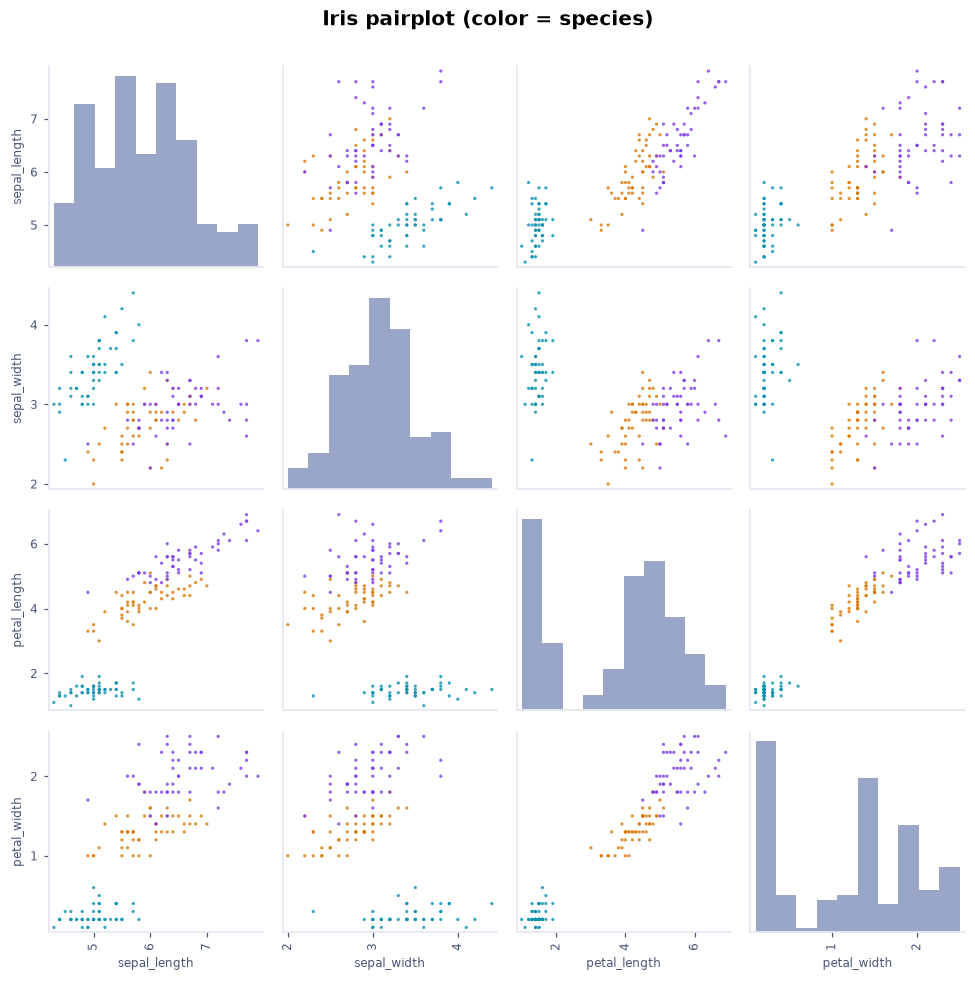

setosa (cyan) separates cleanly on petal size; the other two overlap. One figure, all pairs.


In [3]:
cmap = {"setosa":CYAN, "versicolor":AMBER, "virginica":PURPLE}
colors = df["species"].map(cmap)

axes = pd.plotting.scatter_matrix(df[feat], figsize=(9, 9), diagonal="hist",
                                  color=colors, hist_kwds={"color":"#9aa6c8"},
                                  s=18, alpha=0.8)
for ax in axes.ravel():
    ax.xaxis.label.set_size(8); ax.yaxis.label.set_size(8)
    ax.grid(False)
plt.suptitle("Iris pairplot (color = species)", y=1.0, fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("setosa (cyan) separates cleanly on petal size; the other two overlap. One figure, all pairs.")

<div style="background:#fef3e2;border-left:5px solid #d97706;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#d97706;letter-spacing:1px">DEMO 3 · LORENZ CURVE & GINI</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">📉 A curve with an inequality number</div>
<div style="color:#4a5578;margin-top:6px">Sort people poorest to richest, then plot cumulative share of population against cumulative share of income. The 45-degree line is perfect equality; the more the curve sags below it, the more unequal. The Gini coefficient = 2 x (area of that gap), from 0 (equal) to 1 (one person has everything).</div>
</div>

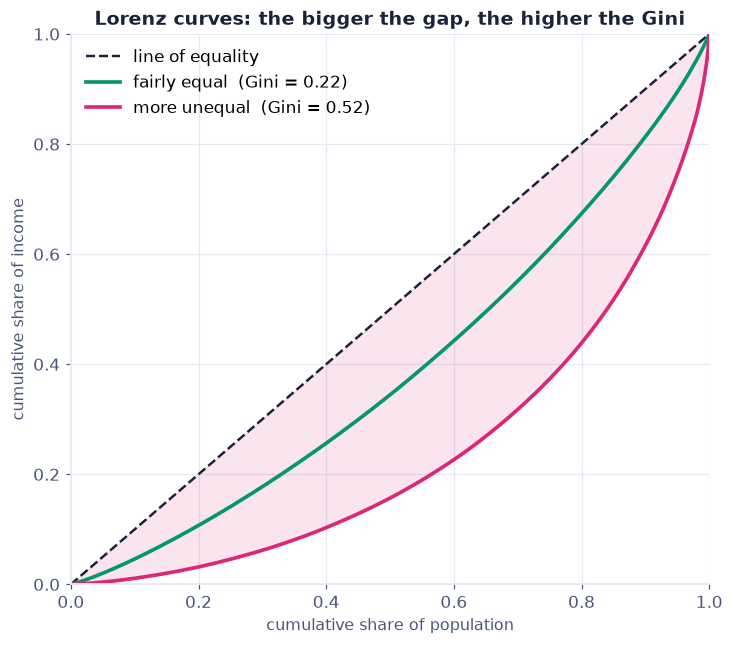

Gini = A/(A+B) = 2A. For reference, real income Ginis run ~0.24 (Slovakia) to ~0.63 (South Africa).


In [4]:
def lorenz_gini(income):
    x = np.sort(income)
    n = len(x)
    cum = np.cumsum(x) / x.sum()
    lor_y = np.concatenate([[0], cum])               # cumulative income share
    lor_x = np.linspace(0, 1, n + 1)                  # cumulative population share
    area_under = np.sum((lor_x[1:] - lor_x[:-1]) * (lor_y[1:] + lor_y[:-1]) / 2)  # trapezoidal rule
    gini = 1 - 2 * area_under                         # G = 1 - 2*(area under Lorenz)
    return lor_x, lor_y, gini

equalish  = rng.lognormal(mean=3.0, sigma=0.4, size=2000)   # fairly equal
unequal   = rng.lognormal(mean=3.0, sigma=1.0, size=2000)   # more unequal

fig, ax = plt.subplots(figsize=(6.8, 6))
ax.plot([0,1],[0,1], color=INK, ls="--", lw=1.6, label="line of equality")
for inc, c, name in [(equalish, GREEN, "fairly equal"), (unequal, PINK, "more unequal")]:
    lx, ly, g = lorenz_gini(inc)
    ax.plot(lx, ly, color=c, lw=2.4, label=f"{name}  (Gini = {g:.2f})")
lx, ly, g = lorenz_gini(unequal)
ax.fill_between(lx, ly, lx, color=PINK, alpha=0.12)
ax.set_xlabel("cumulative share of population"); ax.set_ylabel("cumulative share of income")
ax.set_title("Lorenz curves: the bigger the gap, the higher the Gini"); ax.legend(loc="upper left")
ax.set_xlim(0,1); ax.set_ylim(0,1)
plt.tight_layout(); plt.show()
print("Gini = A/(A+B) = 2A. For reference, real income Ginis run ~0.24 (Slovakia) to ~0.63 (South Africa).")

<div style="background:#e3f6ee;border-left:5px solid #059669;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#059669;letter-spacing:1px">DEMO 4 · SMALL MULTIPLES</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🗂️ Add a dimension, honestly</div>
<div style="color:#4a5578;margin-top:6px">Instead of cramming a third variable into color plus size plus shape, repeat one clean chart once per category and lock the axes identical across panels. Faceting keeps the strong position channel in every panel and stays easy to compare.</div>
</div>

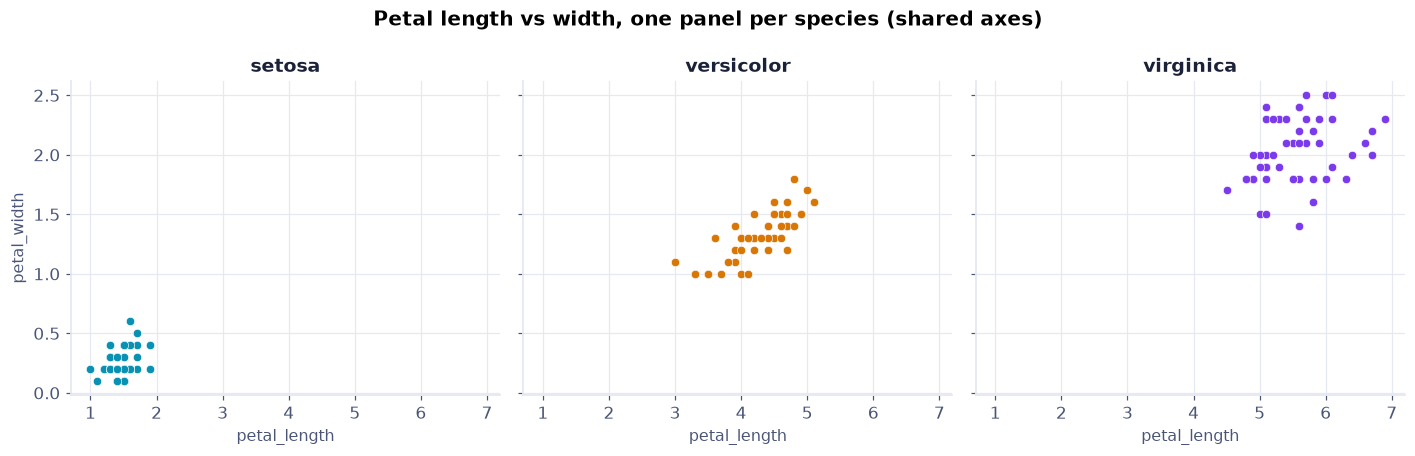

Shared axes make the panels comparable: each species sits in its own region of the same space.


In [5]:
species = list(df["species"].cat.categories)
fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, sp, c in zip(axes, species, [CYAN, AMBER, PURPLE]):
    sub = df[df["species"] == sp]
    ax.scatter(sub["petal_length"], sub["petal_width"], color=c, s=30, edgecolor="white", linewidth=0.4)
    ax.set_title(sp); ax.set_xlabel("petal_length")
axes[0].set_ylabel("petal_width")
plt.suptitle("Petal length vs width, one panel per species (shared axes)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()
print("Shared axes make the panels comparable: each species sits in its own region of the same space.")

<div style="background:#e6effe;border-left:5px solid #2563eb;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#2563eb;letter-spacing:1px">DEMO 5 · AREA, NOT RADIUS</span>
<div style="font-size:22px;font-weight:800;color:#1a2138;margin-top:4px">🫧 Sizing a bubble correctly</div>
<div style="color:#4a5578;margin-top:6px">A bubble chart adds a third variable as marker size. The rule: encode the value as AREA, not radius. matplotlib's s argument is area, so pass the value to s. Square it (radius-scaling) and a 3x value balloons to look 9x bigger.</div>
</div>

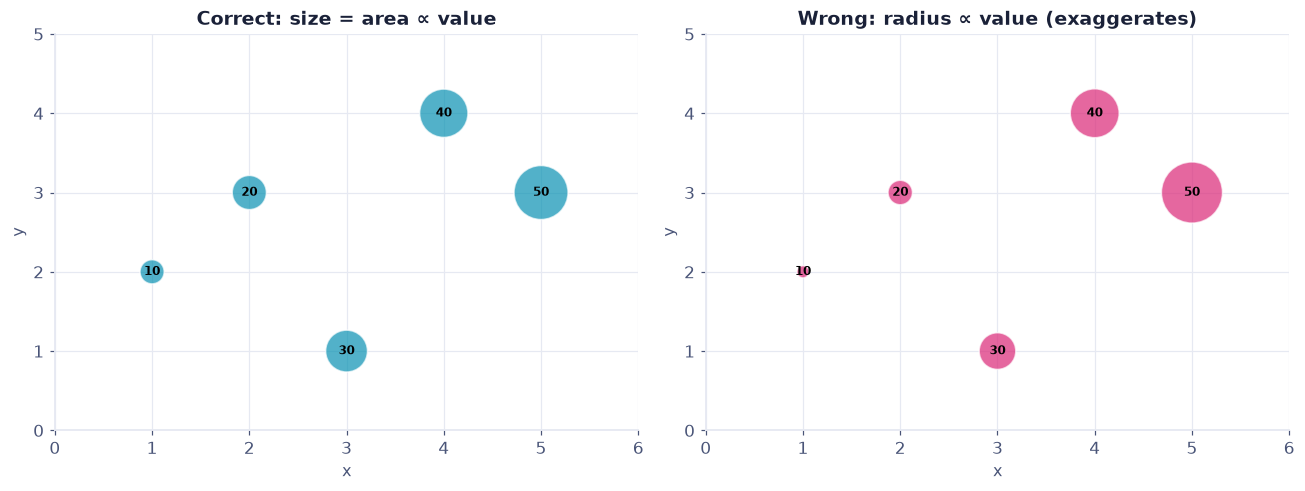

Same values, two stories. Radius-scaling makes 50 look 25x the size of 10, not 5x. Always size by area.


In [6]:
cats = ["A","B","C","D","E"]
xv = np.array([1,2,3,4,5]); yv = np.array([2,3,1,4,3]); val = np.array([10,20,30,40,50.0])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.6))
a1.scatter(xv, yv, s=val*25, color=CYAN, alpha=0.7, edgecolor="white")     # area ∝ value  (correct)
a1.set_title("Correct: size = area ∝ value")
a2.scatter(xv, yv, s=(val*0.8)**2, color=PINK, alpha=0.7, edgecolor="white")  # area ∝ value²  (wrong)
a2.set_title("Wrong: radius ∝ value (exaggerates)")
for ax in (a1, a2):
    for x,y,v in zip(xv,yv,val): ax.text(x, y, int(v), ha="center", va="center", fontsize=8, fontweight="bold")
    ax.set_xlim(0,6); ax.set_ylim(0,5); ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout(); plt.show()
print("Same values, two stories. Radius-scaling makes 50 look 25x the size of 10, not 5x. Always size by area.")

## 🚗 Real-World Example: Car Specifications
Cars are a naturally multivariate dataset, weight, power, economy, and price all move together. We use two multivariate views on 250 vehicles: a **scatter** of weight against fuel economy (colored by region), which shows a strong negative relationship, and a **correlation heatmap** that lays out every pairwise link at once, exactly the screen a data scientist runs before modeling.

correlation with mpg: {'weight_kg': -0.85, 'horsepower': -0.71, 'price_usd': -0.56}
weight vs horsepower r = 0.83


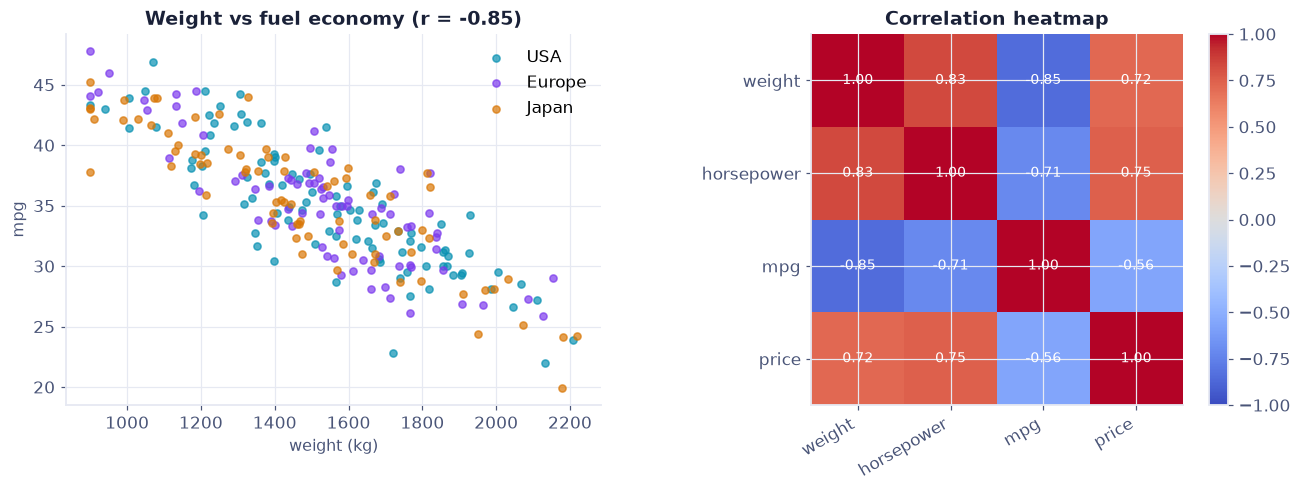

In [7]:
# --- Real-World beat: scatter + correlation heatmap on related columns ---
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
try:    cars = pd.read_excel("../../data/ch16_cars.xlsx", sheet_name="Data")
except FileNotFoundError: cars = pd.read_excel(BASE+"ch16_cars.xlsx", sheet_name="Data")
num = ["weight_kg", "horsepower", "mpg", "price_usd"]
corr = cars[num].corr()
print("correlation with mpg:", corr["mpg"].drop("mpg").round(2).to_dict())
print("weight vs horsepower r =", round(corr.loc["weight_kg","horsepower"], 2))
fig, ax = plt.subplots(1, 2, figsize=(12,4.6))
for org, col in [("USA", CYAN), ("Europe", PURPLE), ("Japan", AMBER)]:
    s = cars[cars.origin==org]; ax[0].scatter(s.weight_kg, s.mpg, s=22, alpha=0.7, color=col, label=org)
ax[0].set_title(f"Weight vs fuel economy (r = {corr.loc['weight_kg','mpg']:.2f})")
ax[0].set_xlabel("weight (kg)"); ax[0].set_ylabel("mpg"); ax[0].legend()
im = ax[1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax[1].set_xticks(range(len(num))); ax[1].set_xticklabels([c.split('_')[0] for c in num], rotation=30, ha="right")
ax[1].set_yticks(range(len(num))); ax[1].set_yticklabels([c.split('_')[0] for c in num])
for i in range(len(num)):
    for j in range(len(num)):
        ax[1].text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=9,
                   color="white" if abs(corr.iloc[i,j])>0.5 else "#1a2138")
ax[1].set_title("Correlation heatmap"); fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

---
<div style="background:#ffffff;border:1px solid #e6e9f2;border-radius:16px;padding:24px 28px;font-family:Inter,sans-serif;box-shadow:0 8px 30px rgba(20,30,80,0.05)">
<div style="font-size:20px;font-weight:800;color:#1a2138">🎓 Recap</div>
<ul style="color:#4a5578;line-height:1.9;margin-top:10px">
<li>A <b>correlation heatmap</b> uses a diverging scale centered at 0; it shows linear association, never causation.</li>
<li>A <b>scatterplot matrix</b> shows every pairwise relationship and distribution at once, best for a handful of variables.</li>
<li>The <b>Lorenz curve</b> plots cumulative income vs population; <b>Gini = 2 x</b> the gap from equality, 0 to 1.</li>
<li><b>Small multiples</b> add a dimension honestly: one chart per category with shared axes.</li>
<li>Size a <b>bubble by area, not radius</b>; matplotlib's s is already area.</li>
</ul>
</div>

<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:18px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>